In [13]:
import numpy as np
import globals as gl
import nibabel as nb
import os
import matplotlib.pyplot as plt
import pandas as pd
from nitools import spm
import nitools as nt
import warnings
from util import load_matlab_hrf

warnings.filterwarnings("ignore")
plt.style.use('default')


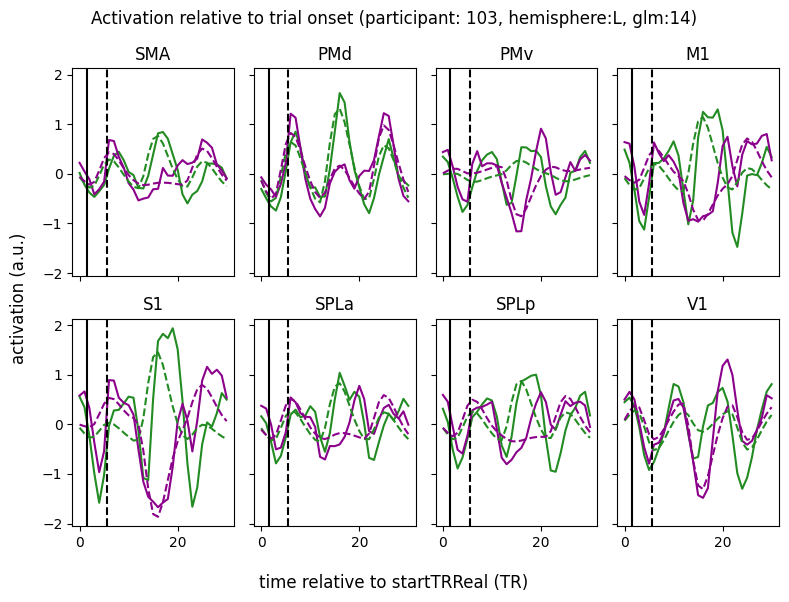

In [14]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 14
sn = 103

path_glm = os.path.join(gl.baseDir, experiment,  f'{gl.glmDir}{glm}', f'subj{sn}', 'T.mat')

T = load_matlab_hrf(path_glm)

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(8, 6))
for i in range(2):
    for j in range(4):

        hem = T['hem']==Hem
        roi = T['name']==rois[r]
        go = T['GoNogo']=='go'

        y_adj_go = np.nanmean(T['y_adj'][go & roi & hem], axis=0)
        y_adj_nogo = np.nanmean(T['y_adj'][~go & roi & hem], axis=0)

        y_hat_go = np.nanmean(T['y_hat'][go & roi & hem], axis=0)
        y_hat_nogo = np.nanmean(T['y_hat'][~go & roi & hem], axis=0)

        axs[i, j].plot(y_adj_go, color='forestgreen', label='go adj', ls='-')
        axs[i, j].plot(y_adj_nogo, color='darkmagenta', label='nogo adj', ls='-')

        axs[i, j].plot(y_hat_go, color='forestgreen', label='go hat', ls='--')
        axs[i, j].plot(y_hat_nogo, color='darkmagenta', label='nogo hat', ls='--')

        axs[i, j].axvline(1.5, color='k', ls='-')
        axs[i, j].axvline(5.5, color='k', ls='--')

        axs[i, j].set_title(rois[r])

        r = r + 1

fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTRReal (TR)')
fig.suptitle(f'Activation relative to trial onset (participant: {sn}, hemisphere:{Hem}, glm:{glm})')

fig.tight_layout()